In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/dow_jones_index.data')

Beginning Walk-Forward Follower Simulation (Active Trading Version)...

Week   | Date         | 1-W Portfolio   | 2-W Portfolio   | All 30 Portfolio 
----------------------------------------------------------------------------------
10     | 2011-03-11   | $99.34          | $97.74          | $98.90           
11     | 2011-03-18   | $99.34          | $95.90          | $97.74           
12     | 2011-03-25   | $101.85         | $95.90          | $99.20           
13     | 2011-04-01   | $101.71         | $94.87          | $100.03          
14     | 2011-04-08   | $101.21         | $96.93          | $100.20          
15     | 2011-04-15   | $102.00         | $96.83          | $99.48           
16     | 2011-04-21   | $102.73         | $98.05          | $101.45          
17     | 2011-04-29   | $103.90         | $100.17         | $103.93          
18     | 2011-05-06   | $102.71         | $99.20          | $102.56          
19     | 2011-05-13   | $102.71         | $102.00         | $102.

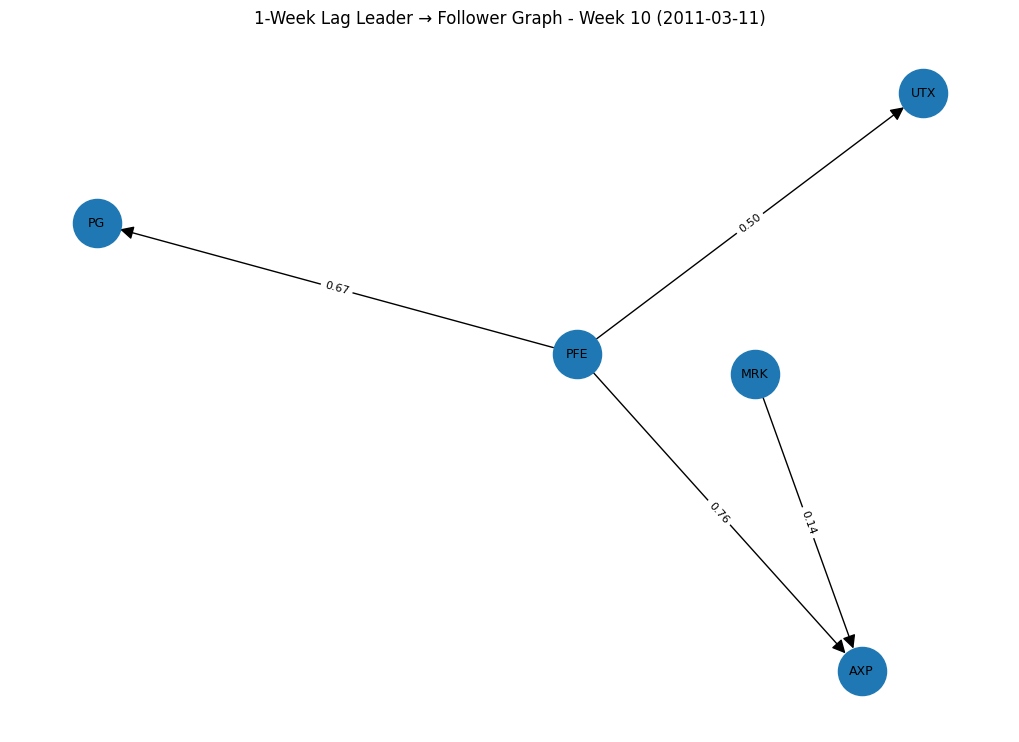

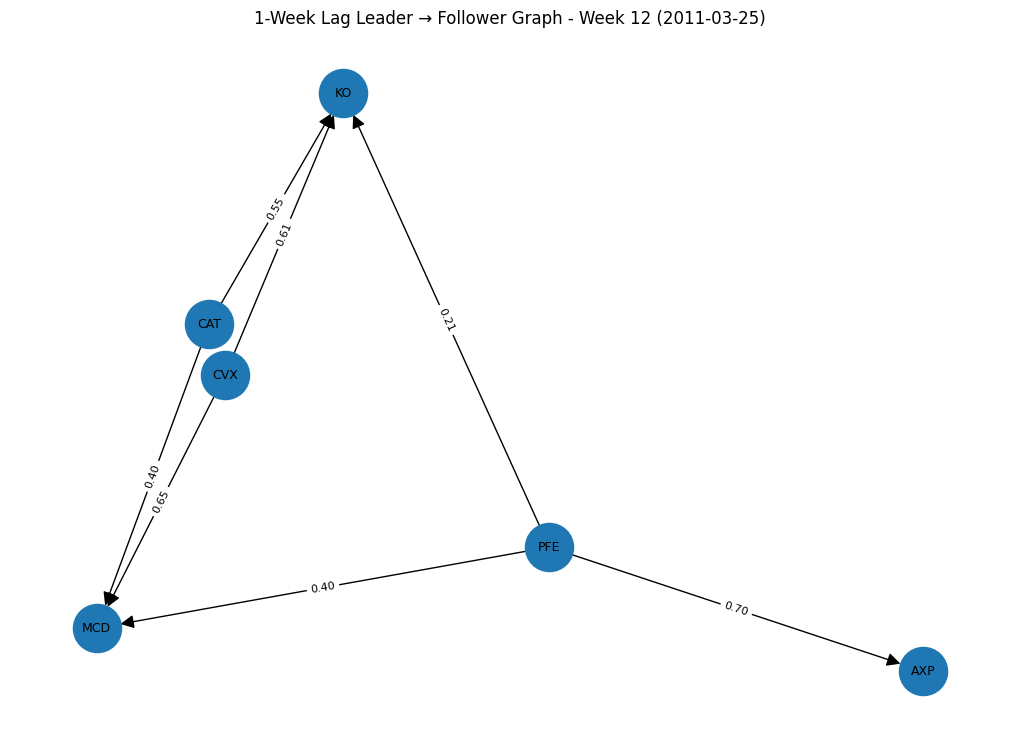

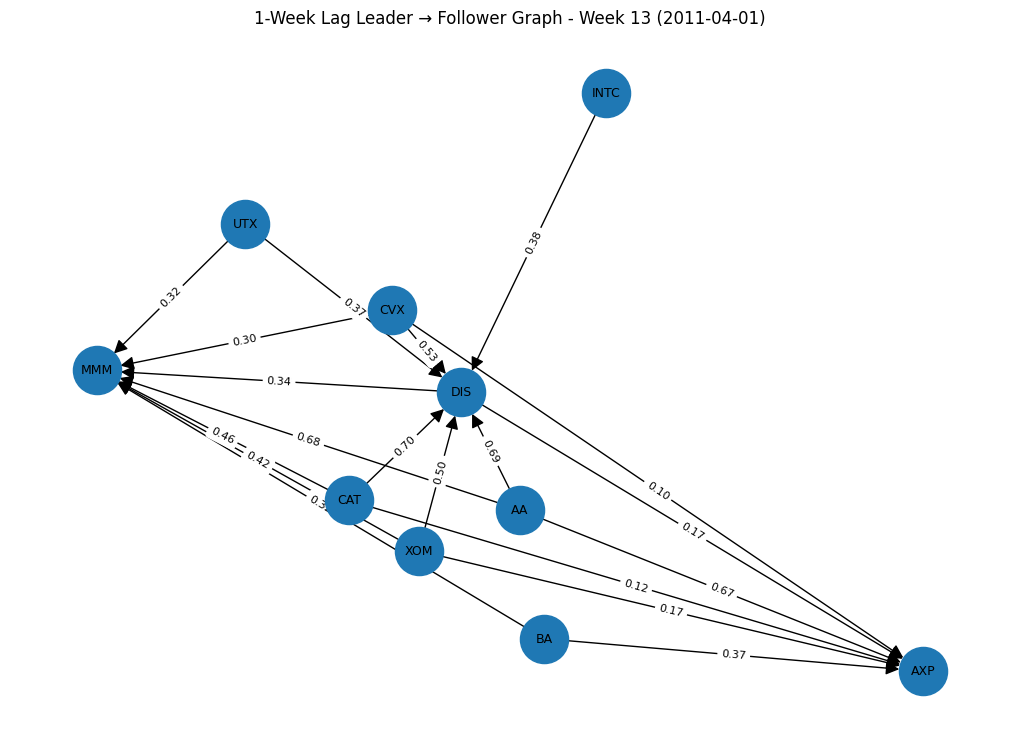

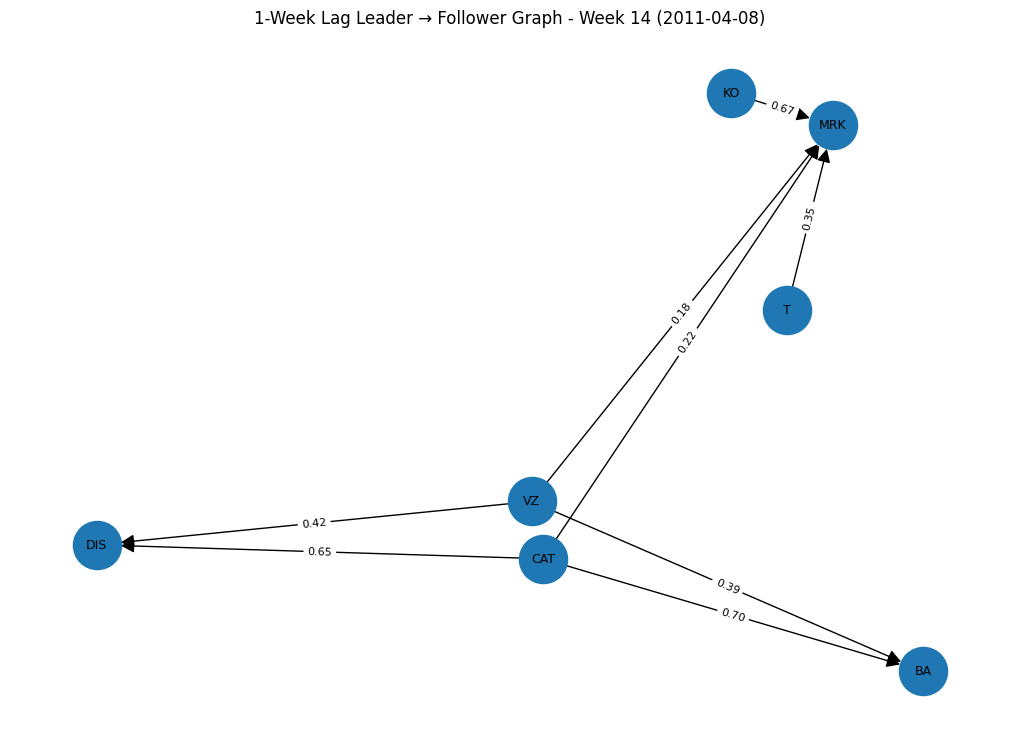

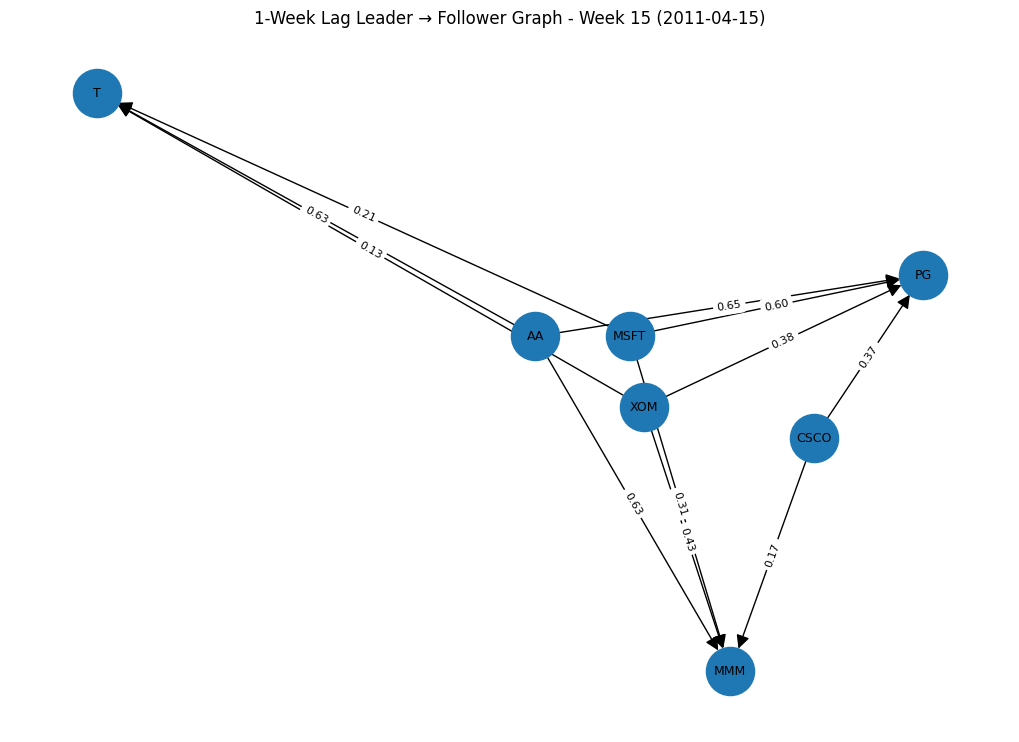

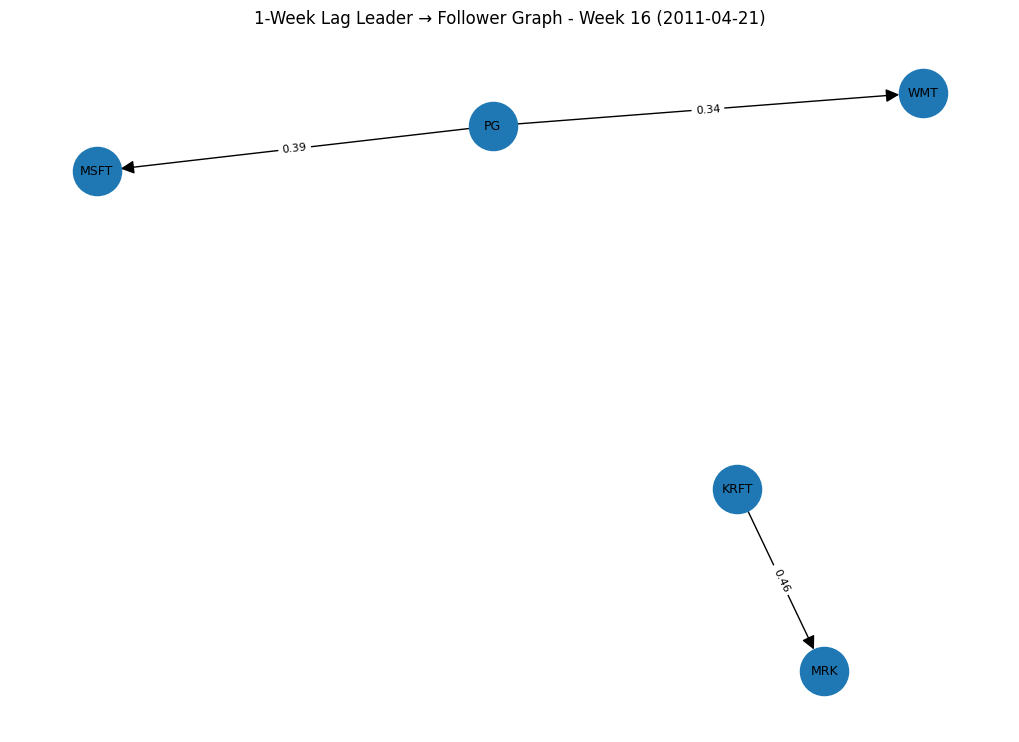

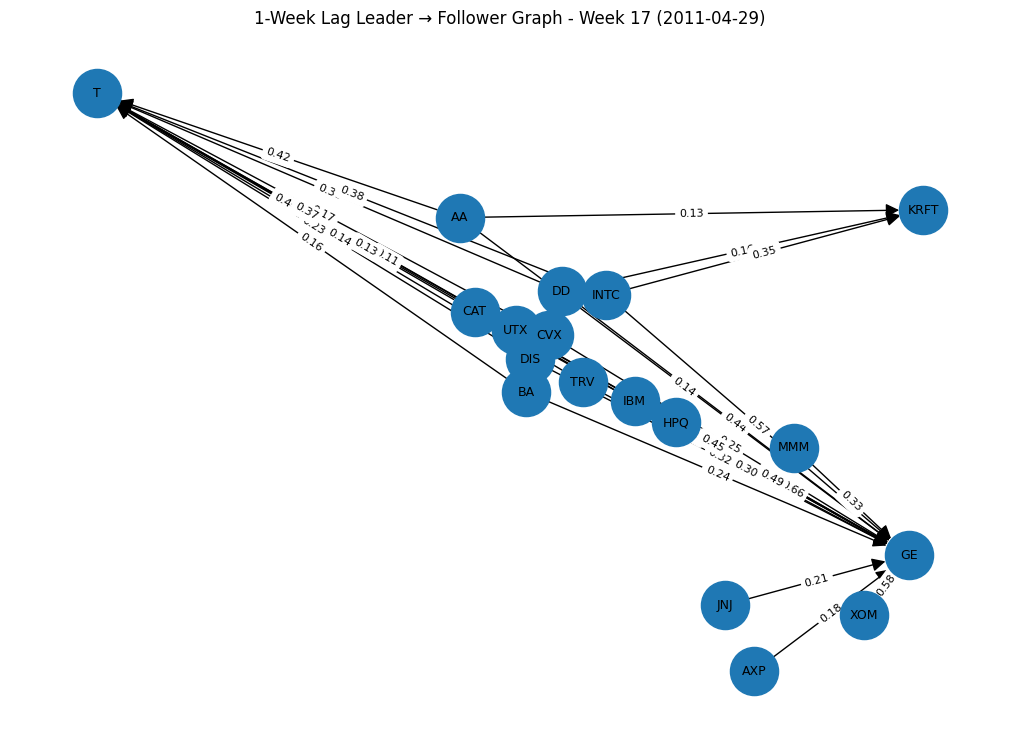

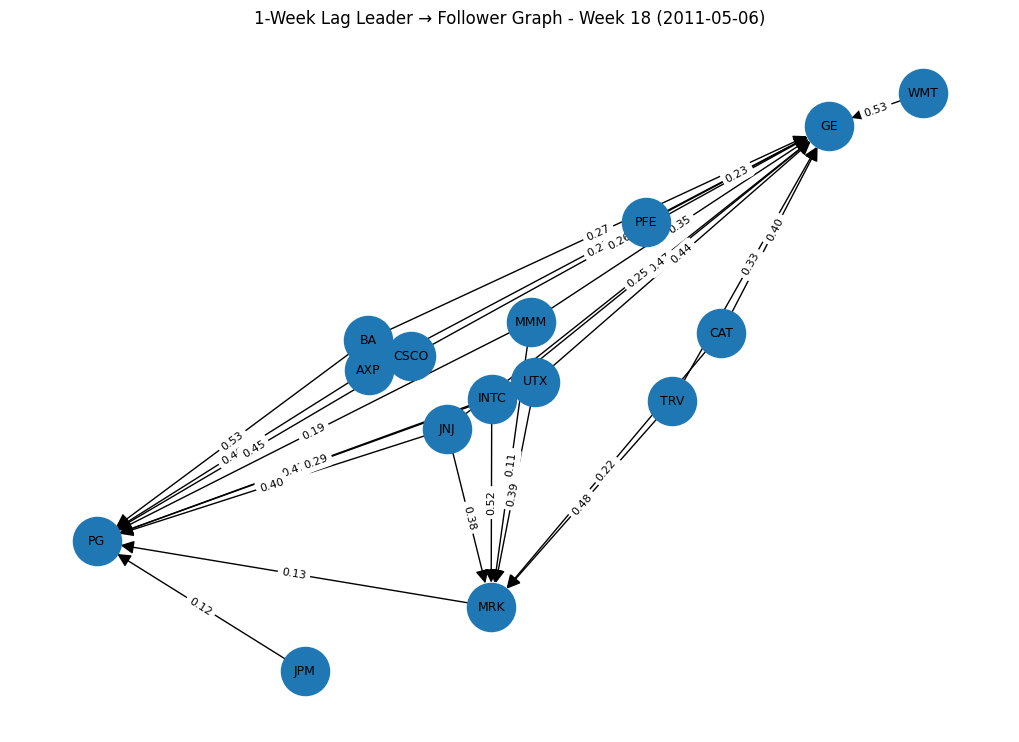

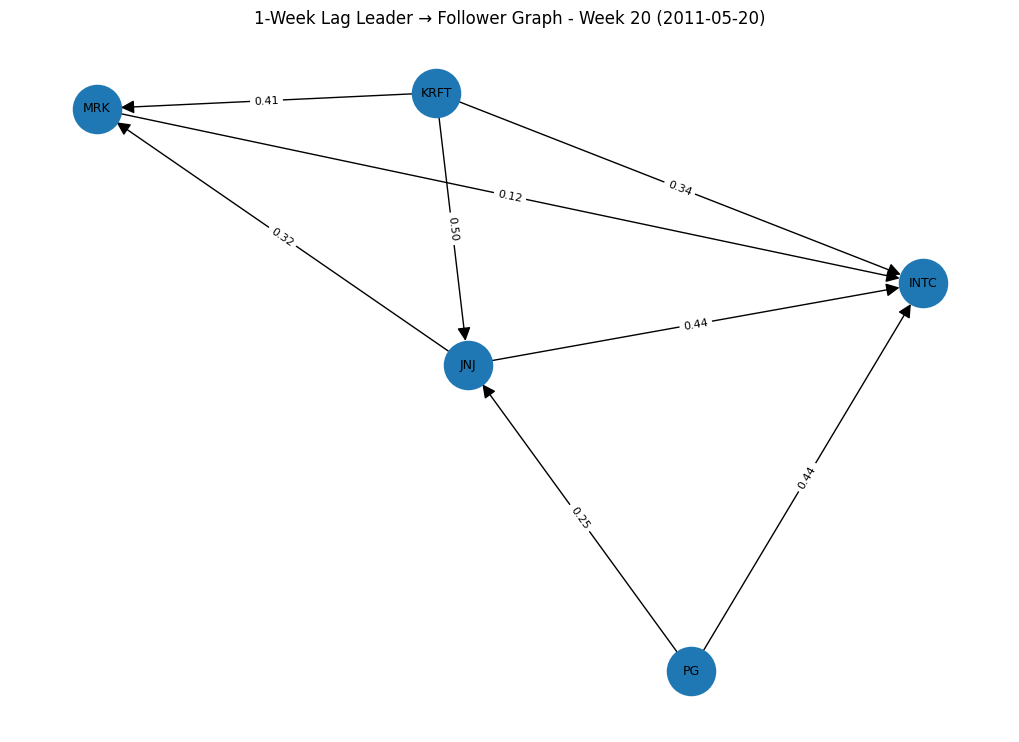

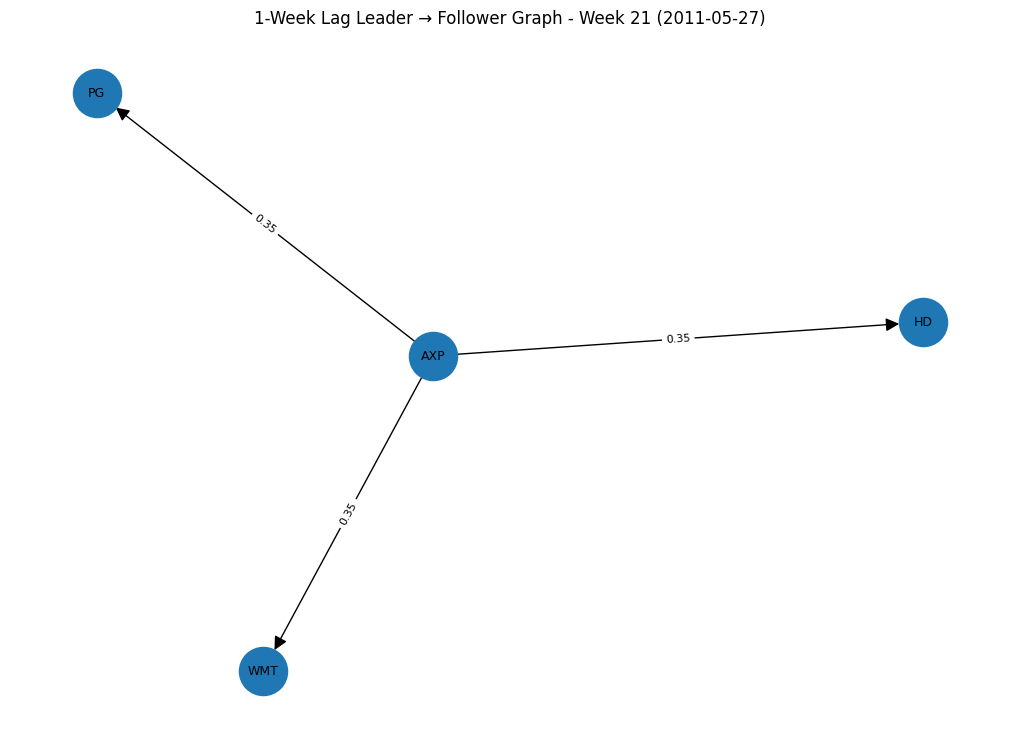

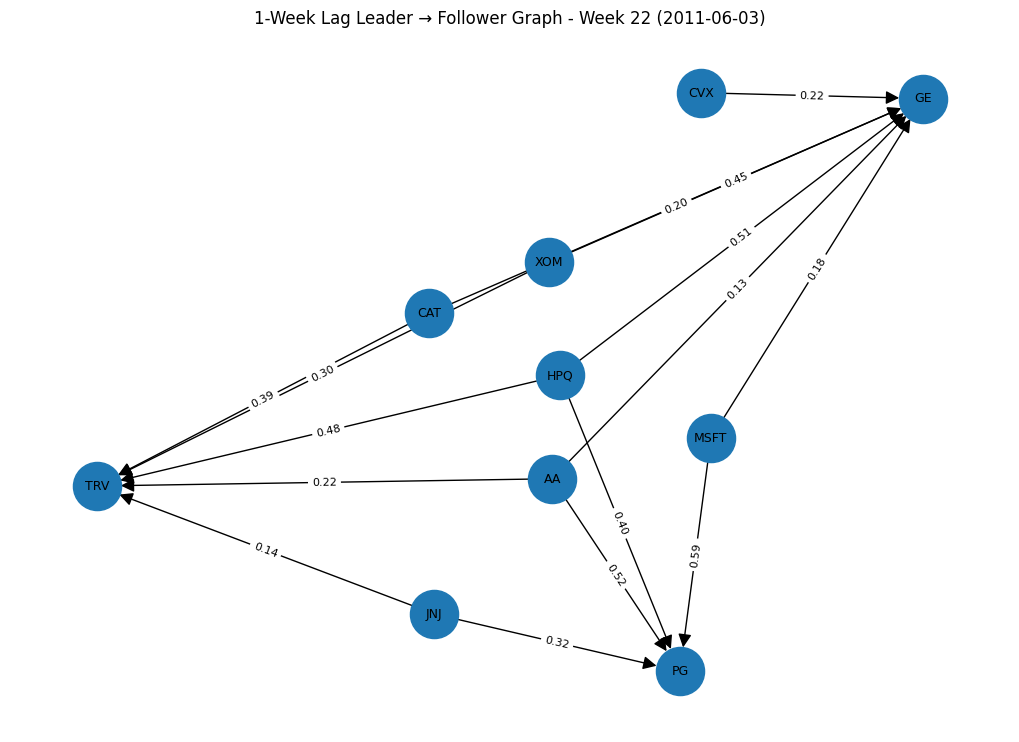

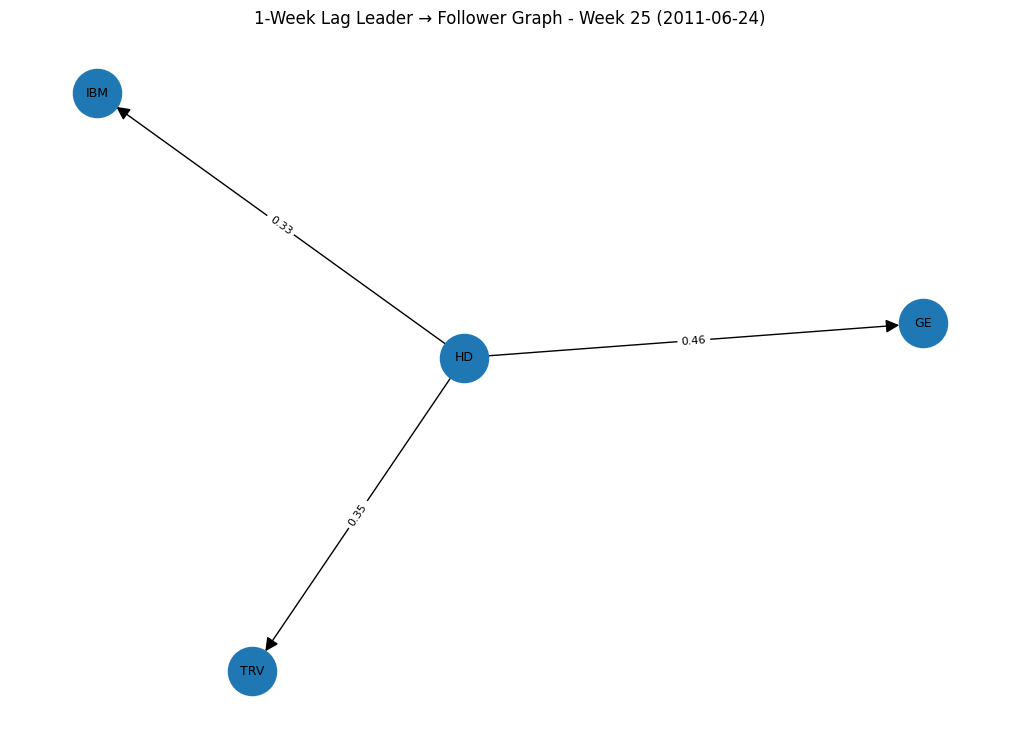

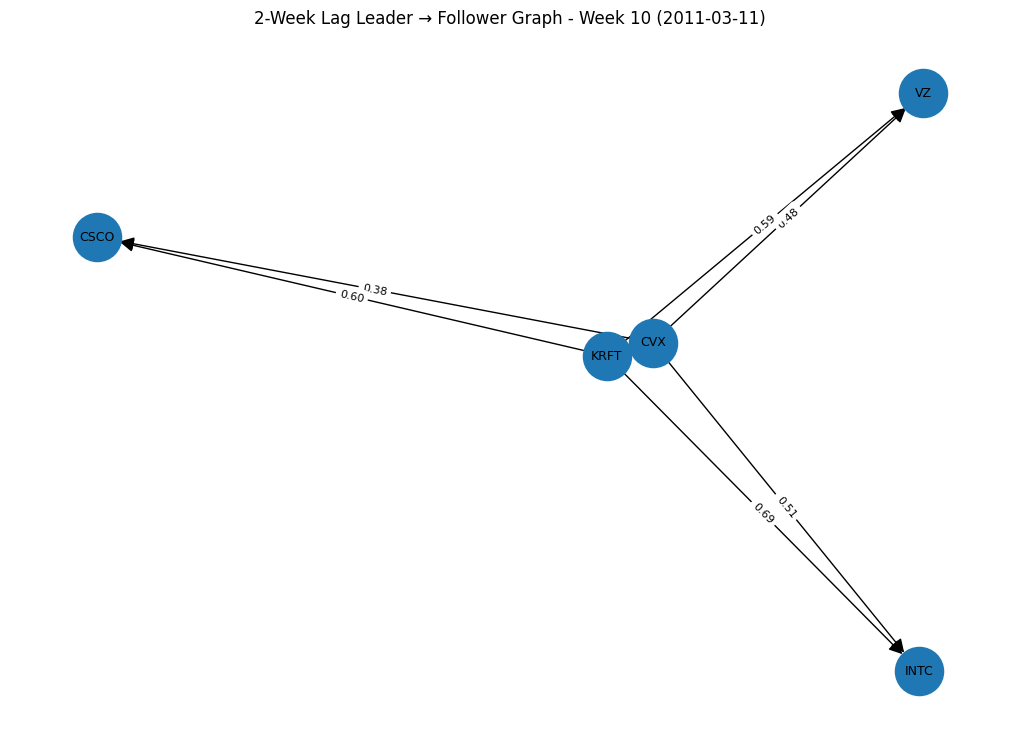

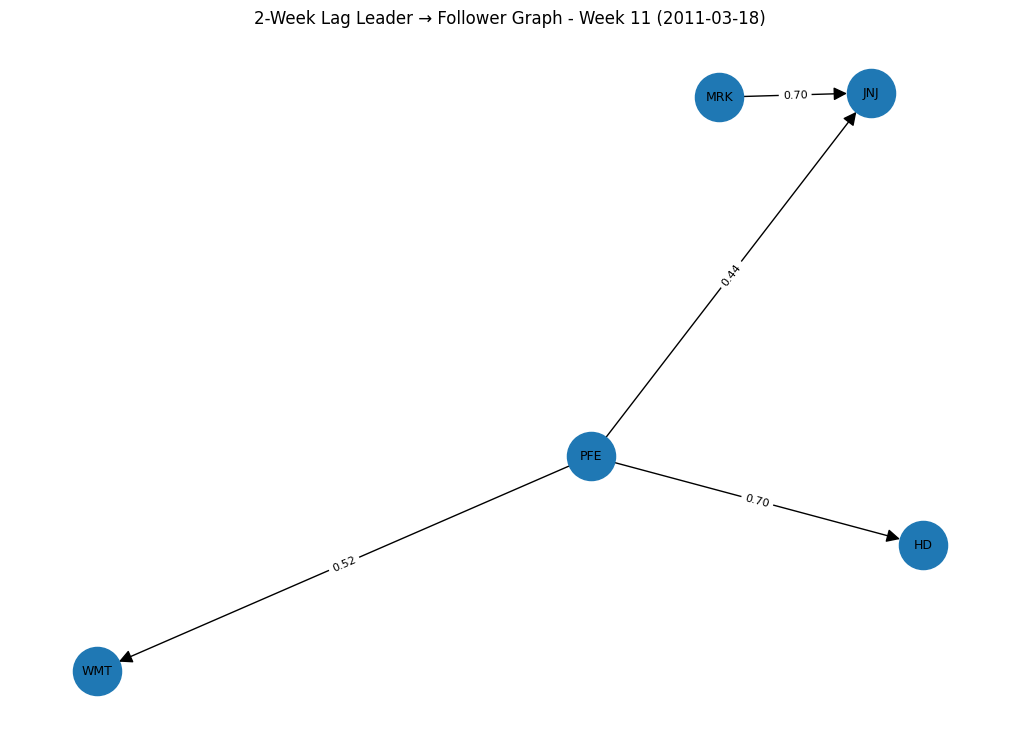

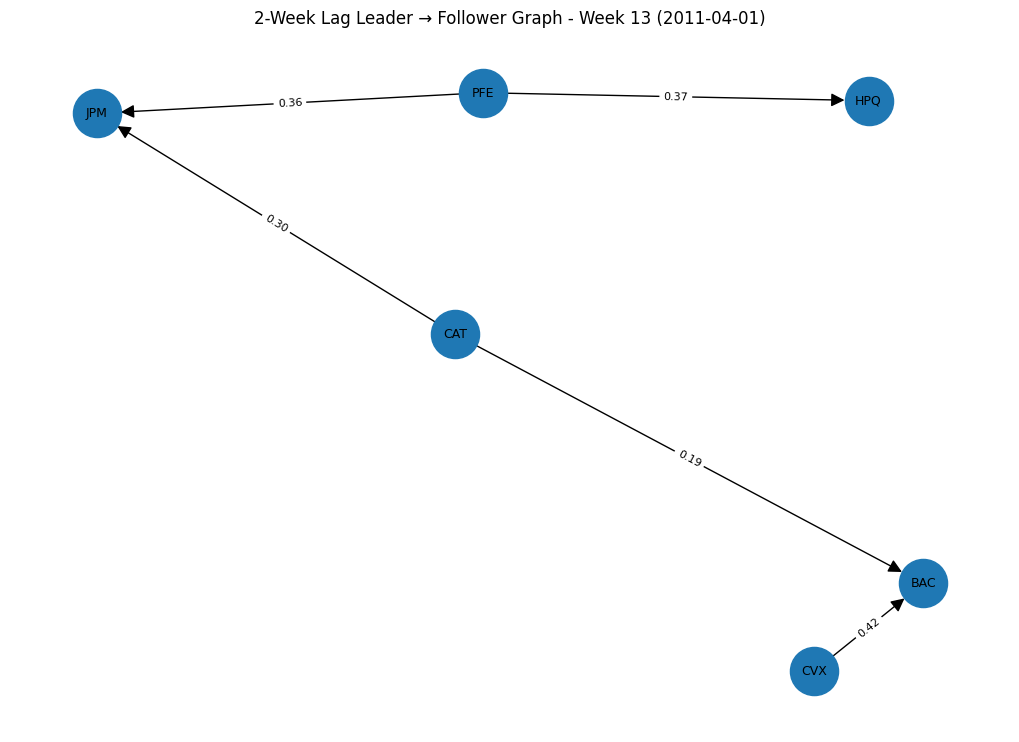

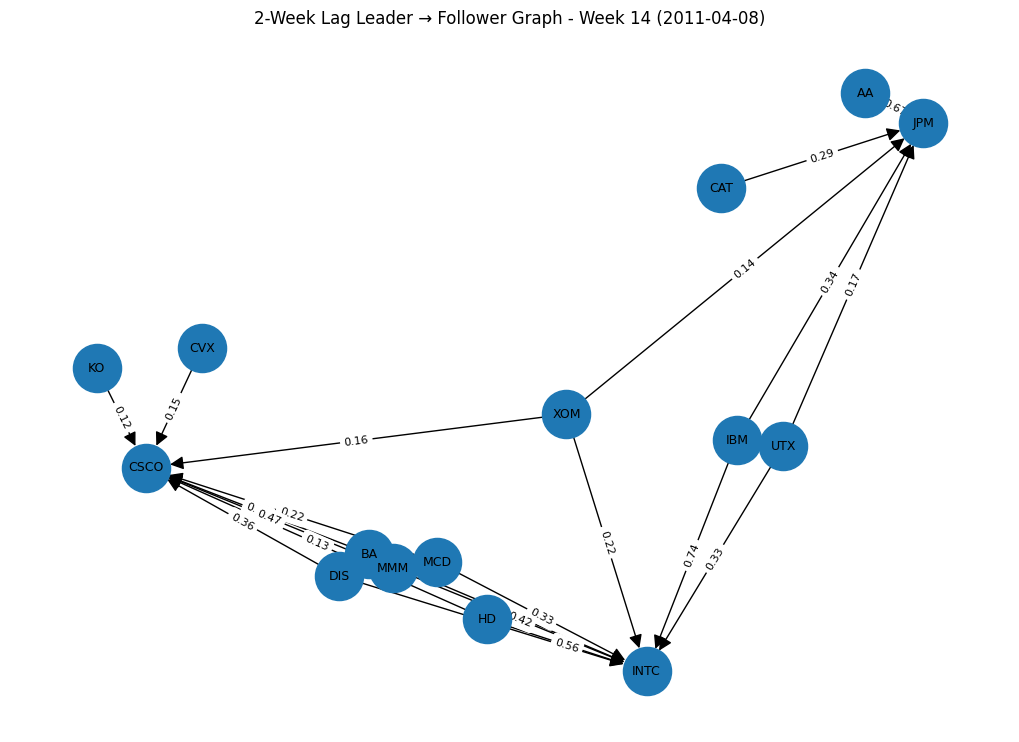

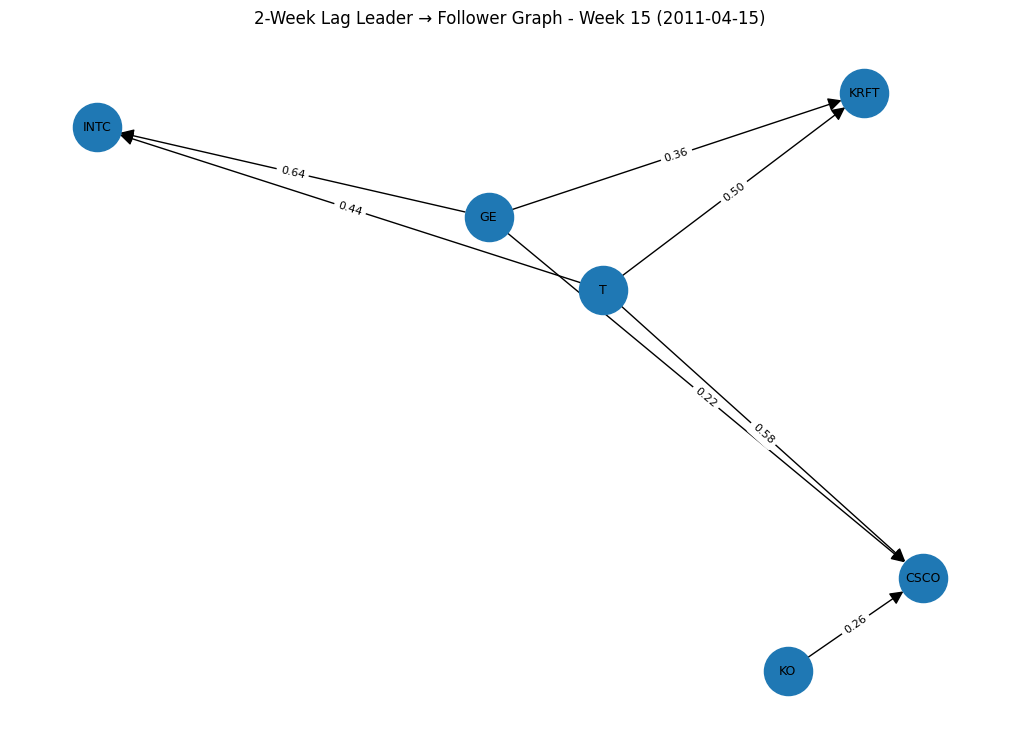

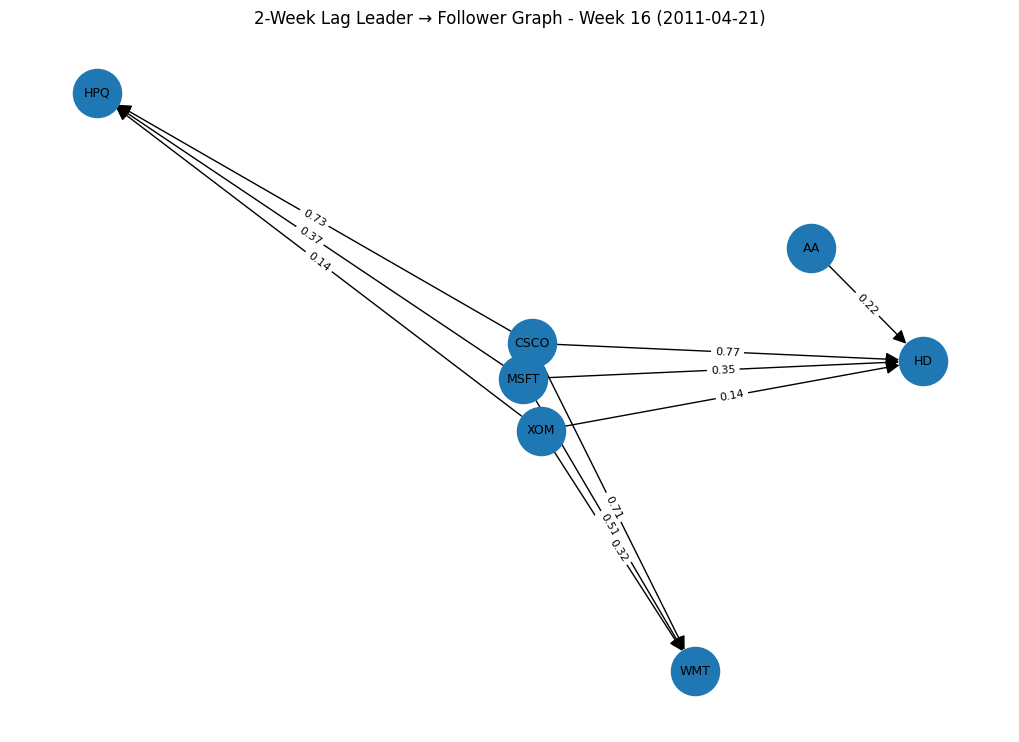

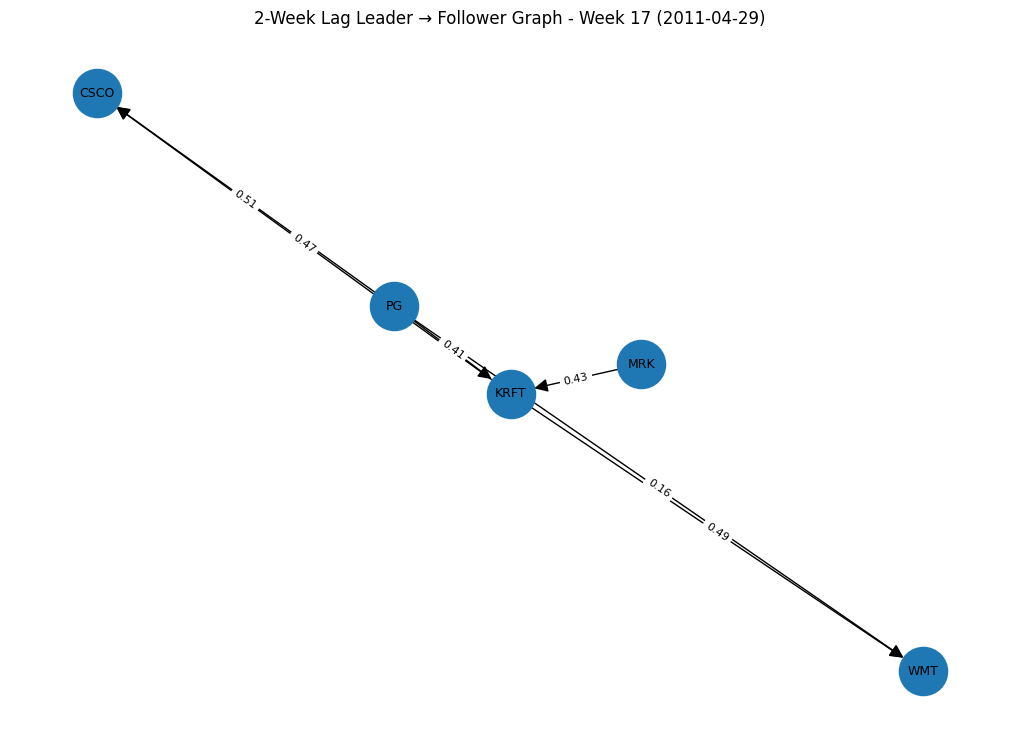

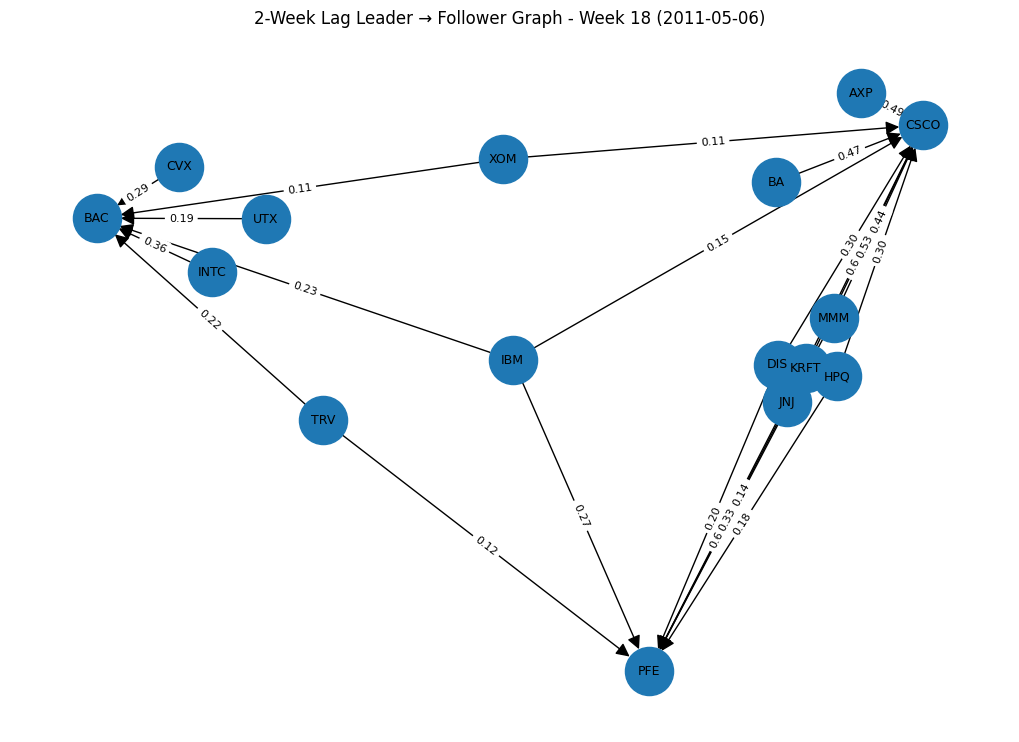

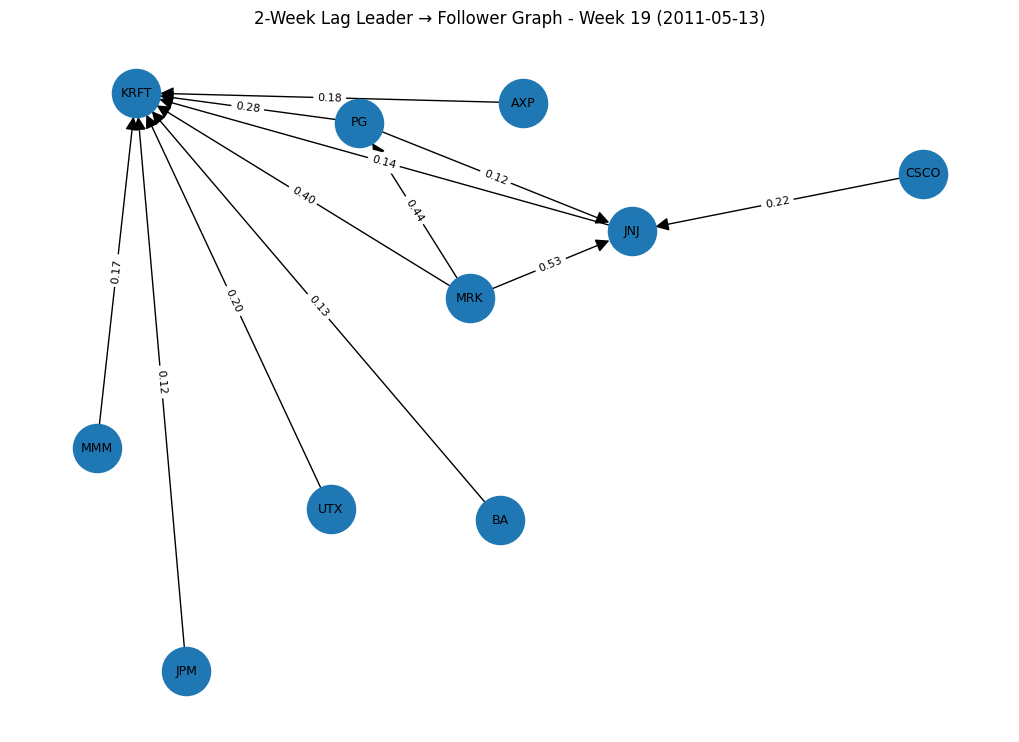

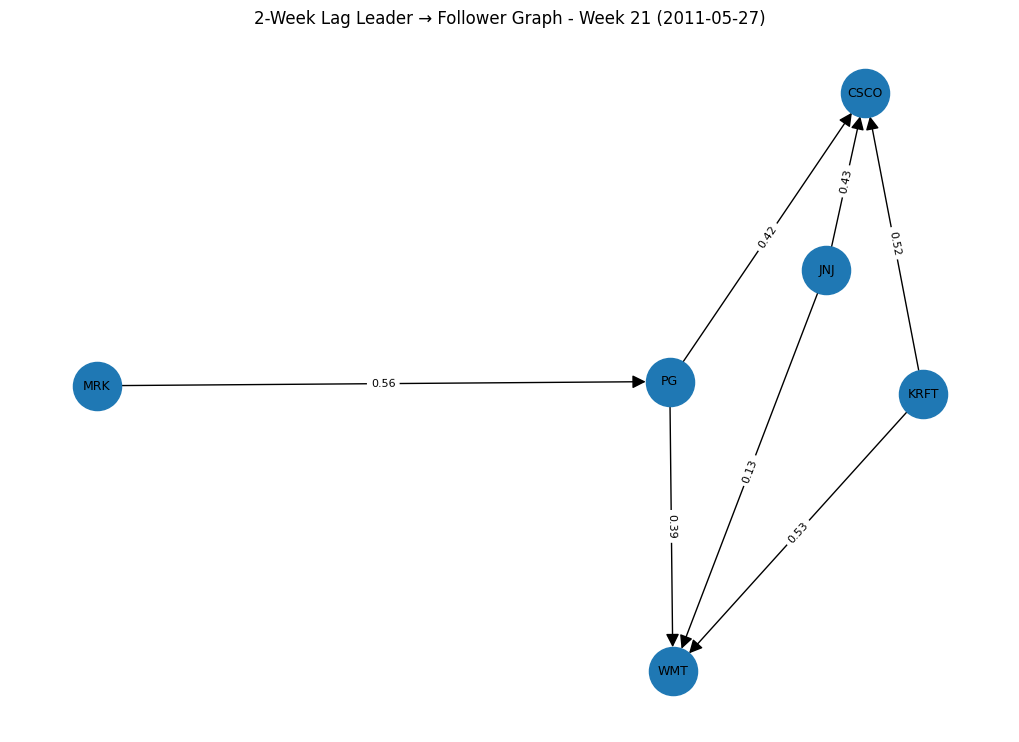

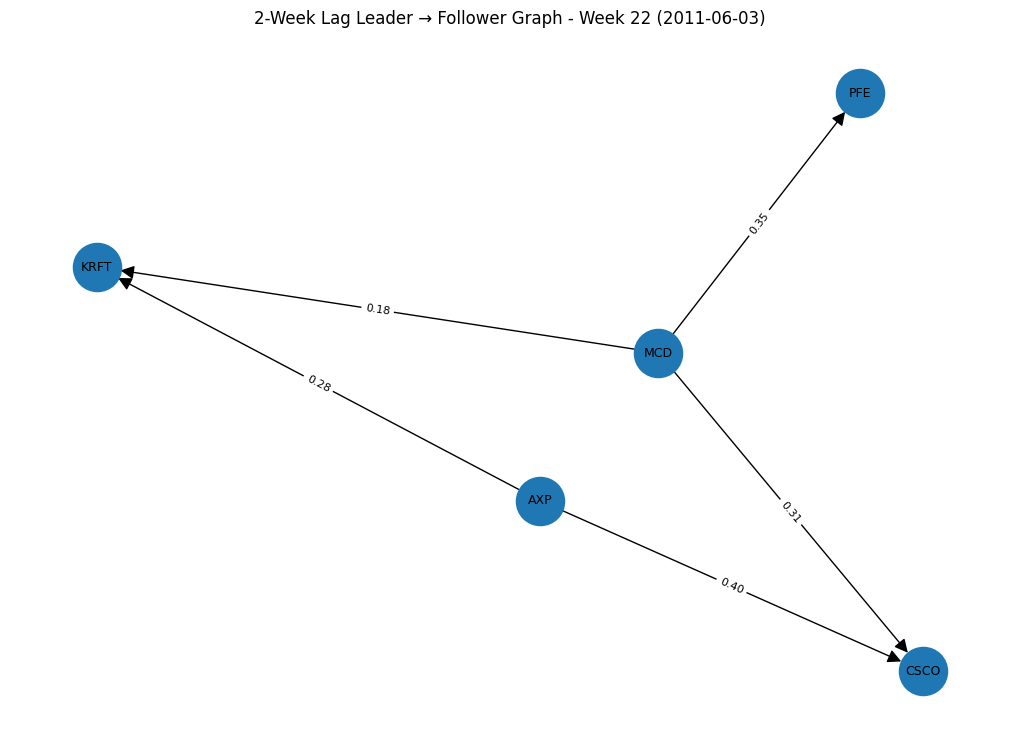

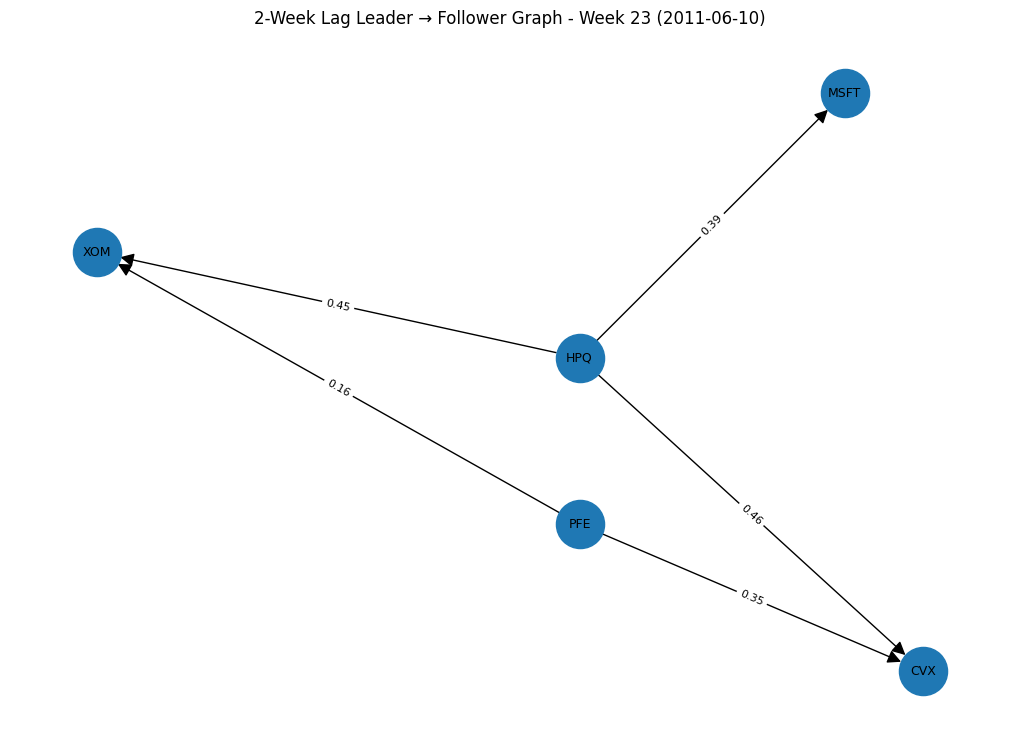

In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('/content/dow_jones_index.data')
df['date'] = pd.to_datetime(df['date'])

# Narrowing down the data and cleaning it
pivot_df = df.pivot(index='date', columns='stock', values='percent_change_price').sort_index()
unique_dates = pivot_df.index

# Initialize portfolios starting with $100.00 cash
cash_1w = 100.00
cash_2w = 100.00
cash_all30 = 100.00

START_WEEK = 10
weekly_edges_1w = {}
weekly_edges_2w = {}

history_1w = []
history_2w = []
history_all30 = []

print(f"Beginning Walk-Forward Follower Simulation (Active Trading Version)...\n")

# 2. run week by week simulation
for current_idx in range(len(unique_dates)):
    current_date = unique_dates[current_idx]

# for all of them
    if current_idx >= 9:
        weekly_returns = pivot_df.loc[current_date].dropna()

        if len(weekly_returns) > 0:
            avg_return = weekly_returns.mean()
            cash_all30 = cash_all30 * (1 + avg_return / 100.0)

        history_all30.append((current_date.strftime('%Y-%m-%d'), cash_all30))

    #1 week lag

    if current_idx >= 9:
        historical_data = pivot_df.iloc[:current_idx].copy()

        leader_matrix = historical_data.iloc[:-1]
        follower_matrix = historical_data.shift(-1).iloc[:-1]

        # Cross correlations matrix
        lag_corr_matrix = pd.DataFrame(0.0, index=pivot_df.columns, columns=pivot_df.columns)
        for follower in pivot_df.columns:
            for leader in pivot_df.columns:
                if leader != follower:
                    corr = leader_matrix[leader].corr(follower_matrix[follower])
                    lag_corr_matrix.at[leader, follower] = corr if pd.notna(corr) else 0.0

        combined_scores = {}
        last_week_date = unique_dates[current_idx - 1]

        for stock in pivot_df.columns:
            all_leaders = lag_corr_matrix[stock]
            positive_leaders = all_leaders[all_leaders > 0.1] # Correlation barrier (picked 0.1 arbitrarily)

            leader_triggered = False
            max_leader_return = 0.0

            for leader, correlation_weight in positive_leaders.items():
                leader_perf_last_week = pivot_df.at[last_week_date, leader]
                if pd.notna(leader_perf_last_week) and leader_perf_last_week > 2.0: #picked 2 percent because it sounded reasonable?
                    leader_triggered = True
                    max_leader_return = max(max_leader_return, leader_perf_last_week * correlation_weight)

            if leader_triggered:
                combined_scores[stock] = max_leader_return
            else:
                combined_scores[stock] = 0.0

        # Select Top 3 valid followers
        valid_scores = {k: v for k, v in combined_scores.items() if v > 0}
        top_3_stocks = sorted(valid_scores.items(), key=lambda x: x[1], reverse=True)[:3]

        # Store graph edges (1-week strategy)
        edges_this_week = []

        for follower, score in top_3_stocks:
            for leader, corr in lag_corr_matrix[follower].items():

                if corr > 0.1:

                    leader_return = pivot_df.at[last_week_date, leader]

                    if pd.notna(leader_return) and leader_return > 2.0:
                        edges_this_week.append((leader, follower, corr))

        weekly_edges_1w[current_date] = edges_this_week

        if top_3_stocks:
            new_cash = 0
            allocation_per_stock = cash_1w / len(top_3_stocks)

            for stock, _ in top_3_stocks:
                actual_return = pivot_df.at[current_date, stock]
                if pd.notna(actual_return):
                    new_cash += allocation_per_stock * (1 + (actual_return / 100.0))
                else:
                    new_cash += allocation_per_stock
            cash_1w = new_cash

        history_1w.append((current_date.strftime('%Y-%m-%d'), cash_1w))

    # 2 week lag
    if current_idx >= 9:
        historical_data = pivot_df.iloc[:current_idx].copy()

        leader_matrix = historical_data.iloc[:-2]
        follower_matrix = historical_data.shift(-2).iloc[:-2]

        # Cross correlations
        lag_corr_matrix = pd.DataFrame(0.0, index=pivot_df.columns, columns=pivot_df.columns)
        for follower in pivot_df.columns:
            for leader in pivot_df.columns:
                if leader != follower:
                    corr = leader_matrix[leader].corr(follower_matrix[follower])
                    lag_corr_matrix.at[leader, follower] = corr if pd.notna(corr) else 0.0

        combined_scores = {}
        trigger_date = unique_dates[current_idx - 2]

        for stock in pivot_df.columns:
            all_leaders = lag_corr_matrix[stock]
            positive_leaders = all_leaders[all_leaders > 0.1]

            leader_triggered = False
            max_leader_return = 0.0

            for leader, correlation_weight in positive_leaders.items():
                leader_perf_trigger_week = pivot_df.at[trigger_date, leader]
                if pd.notna(leader_perf_trigger_week) and leader_perf_trigger_week > 2.0:
                    leader_triggered = True
                    max_leader_return = max(max_leader_return, leader_perf_trigger_week * correlation_weight)

            if leader_triggered:
                combined_scores[stock] = max_leader_return
            else:
                combined_scores[stock] = 0.0

        valid_scores = {k: v for k, v in combined_scores.items() if v > 0}
        top_3_stocks = sorted(valid_scores.items(), key=lambda x: x[1], reverse=True)[:3]

        # Store graph edges (2-week strategy)
        edges_this_week = []

        for follower, score in top_3_stocks:
            for leader, corr in lag_corr_matrix[follower].items():

                if corr > 0.1:

                    leader_return = pivot_df.at[trigger_date, leader]

                    if pd.notna(leader_return) and leader_return > 2.0:
                        edges_this_week.append((leader, follower, corr))

        weekly_edges_2w[current_date] = edges_this_week

        if top_3_stocks:
            new_cash = 0
            allocation_per_stock = cash_2w / len(top_3_stocks)

            for stock, _ in top_3_stocks:
                actual_return = pivot_df.at[current_date, stock]
                if pd.notna(actual_return):
                    new_cash += allocation_per_stock * (1 + (actual_return / 100.0))
                else:
                    new_cash += allocation_per_stock
            cash_2w = new_cash

        history_2w.append((current_date.strftime('%Y-%m-%d'), cash_2w))

# 3. print matrix
print(f"{'Week':<6} | {'Date':<12} | {'1-W Portfolio':<15} | {'2-W Portfolio':<15} | {'All 30 Portfolio':<17}")
print("-" * 82)

all_perf = {}

for i, dt in enumerate(unique_dates):
    dt_str = dt.strftime('%Y-%m-%d')
    all_perf[dt_str] = [100.00, 100.00, 100.00, i + 1]

for dt, val in history_1w:
    all_perf[dt][0] = val

for dt, val in history_2w:
    all_perf[dt][1] = val

for dt, val in history_all30:
    all_perf[dt][2] = val

for dt in sorted(all_perf.keys()):
    cash1, cash2, cash_all, week_num = all_perf[dt]

    if week_num >= START_WEEK:
        print(f"{week_num:<6} | {dt:<12} | ${cash1:<14.2f} | ${cash2:<14.2f} | ${cash_all:<16.2f}")

def plot_weekly_graphs(weekly_edges, title_prefix):
    for current_date, edges in weekly_edges.items():
        week_num = list(unique_dates).index(current_date) + 1

        if week_num < START_WEEK:
            continue

        if not edges:
            continue

        G = nx.DiGraph()

        for leader, follower, corr in edges:
            G.add_edge(leader, follower, weight=corr)

        plt.figure(figsize=(10, 7))
        pos = nx.spring_layout(G, seed=42)

        nx.draw(
            G,
            pos,
            with_labels=True,
            node_size=1200,
            font_size=9,
            arrows=True,
            arrowsize=20
        )

        edge_labels = {
            (u, v): f"{d['weight']:.2f}"
            for u, v, d in G.edges(data=True)
        }

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=8
        )

        plt.title(f"{title_prefix} - Week {week_num} ({current_date.strftime('%Y-%m-%d')})")
        plt.show()


plot_weekly_graphs(weekly_edges_1w, "1-Week Lag Leader → Follower Graph")
plot_weekly_graphs(weekly_edges_2w, "2-Week Lag Leader → Follower Graph")

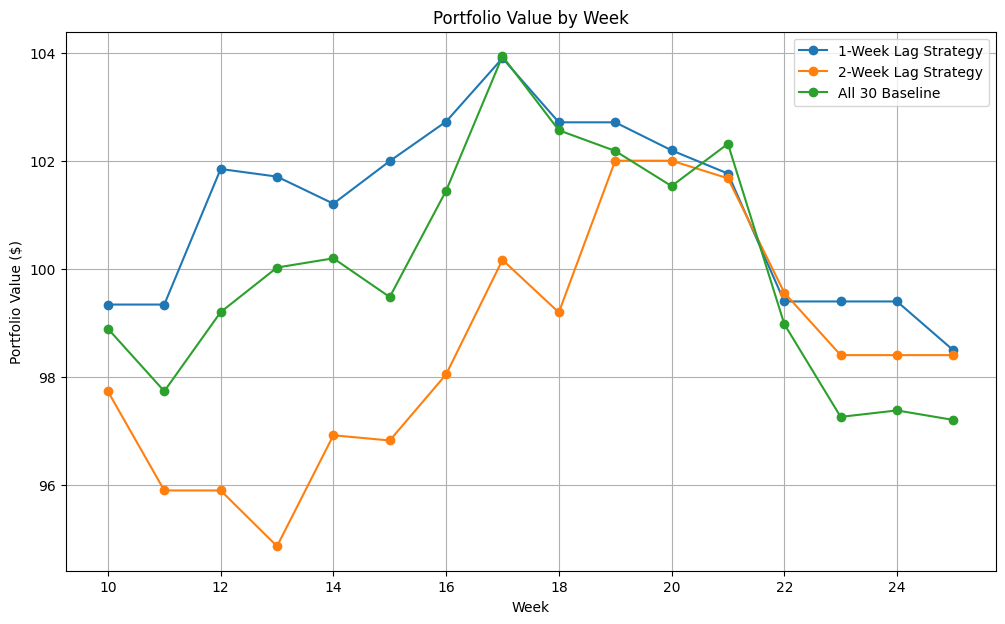

In [4]:
# 4. graph portfolio balances over time

plot_data = []

for dt in sorted(all_perf.keys()):
    cash1, cash2, cash_all, week_num = all_perf[dt]

    if week_num >= START_WEEK:
        plot_data.append({
            "week": week_num,
            "date": dt,
            "1-Week Lag": cash1,
            "2-Week Lag": cash2,
            "All 30 Baseline": cash_all
        })

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))

plt.plot(plot_df["week"], plot_df["1-Week Lag"], marker="o", label="1-Week Lag Strategy")
plt.plot(plot_df["week"], plot_df["2-Week Lag"], marker="o", label="2-Week Lag Strategy")
plt.plot(plot_df["week"], plot_df["All 30 Baseline"], marker="o", label="All 30 Baseline")

plt.xlabel("Week")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value by Week")
plt.legend()
plt.grid(True)
plt.show()